# 05 · Prediction & Business Insights
**Input**: Trained models from `models/` + clustered data from notebook 04  
**Goal**: Score new customers, decode segments, generate marketing playbooks

---
This notebook shows how the trained pipeline is used in production:
1. Load saved artefacts (scaler, model, feature list)
2. Score individual or batch customers
3. Interpret each segment with actionable recommendations


## 1. Setup & load artefacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.float_format', '{:,.2f}'.format)

PROC_DIR  = Path('../data/processed')
MODEL_DIR = Path('../models')
PLOT_DIR  = Path('../docs/eda_plots')

# Load all artefacts saved in notebooks 02 & 04
scaler        = joblib.load(MODEL_DIR / 'scaler.pkl')
kmeans        = joblib.load(MODEL_DIR / 'kmeans_model.pkl')
feature_names = joblib.load(MODEL_DIR / 'feature_names.pkl')
rfm           = pd.read_csv(PROC_DIR / 'rfm_clustered.csv', index_col=0)

print('Artefacts loaded:')
print(f'  scaler        : {type(scaler).__name__}')
print(f'  kmeans        : {type(kmeans).__name__} (k={kmeans.n_clusters})')
print(f'  feature_names : {len(feature_names)} features')
print(f'  rfm           : {rfm.shape[0]:,} customers, {rfm.shape[1]} columns')
print(f'\nFeatures used: {feature_names}')


Artefacts loaded:
  scaler        : RobustScaler
  kmeans        : KMeans (k=4)
  feature_names : 11 features
  rfm           : 3,155 customers, 19 columns

Features used: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TenureDays', 'CLV', 'UniqueProducts', 'AvgBasketSize', 'PurchaseFreqMonthly', 'MonthlySpendCV', 'WeekendShopperRatio']


## 2. Cluster business profiles
Full marketing playbook for each segment — ready to hand to the CRM team.

In [2]:
PROFILES = {
    'Champions': {
        'emoji': '🏆', 'color': '#2ECC71',
        'rfm':   'High R · High F · High M',
        'desc':  'Best customers — bought recently, buy often, spend the most.',
        'strategy': [
            'Enrol in VIP loyalty programme with exclusive perks',
            'Early access to new product launches',
            'Ask for reviews and referrals — highest NPS potential',
            'Personalised "thank you" gift on anniversary',
        ],
        'retention_risk': 'Low', 'upsell': 'Very High',
    },
    'Loyal Customers': {
        'emoji': '💙', 'color': '#3498DB',
        'rfm':   'Medium-High R · High F · High M',
        'desc':  'Regular buyers with strong spend — core revenue drivers.',
        'strategy': [
            'Introduce subscription or auto-replenishment options',
            'Upsell to higher-margin product lines',
            'Personalised product recommendations via email',
            '"Exclusive member" pricing on selected SKUs',
        ],
        'retention_risk': 'Low-Medium', 'upsell': 'High',
    },
    'Potential Loyalists': {
        'emoji': '🌱', 'color': '#9B59B6',
        'rfm':   'High R · Medium F · Medium M',
        'desc':  'Recent customers in the habit-formation window.',
        'strategy': [
            '3-email onboarding journey — product education',
            'Second-purchase discount (7-day expiry)',
            'Introduce loyalty points programme',
            'Category cross-sell based on first purchase',
        ],
        'retention_risk': 'Medium', 'upsell': 'High',
    },
    'At Risk': {
        'emoji': '🚨', 'color': '#E74C3C',
        'rfm':   'Low R · Medium-High F · Medium-High M',
        'desc':  'Were good customers — have not purchased in a long time.',
        'strategy': [
            'Aggressive win-back: 25% discount on favourite category',
            'Personalised "We miss you" email with social proof',
            'Survey to understand what drove drop-off',
            'Phone / chat outreach for highest-value at-risk accounts',
        ],
        'retention_risk': 'Very High', 'upsell': 'Low-Medium',
    },
    'Cannot Lose Them': {
        'emoji': '🔑', 'color': '#C0392B',
        'rfm':   'Very Low R · High F · High M',
        'desc':  'Former Champions — historically high value, now inactive.',
        'strategy': [
            'Personal outreach from account manager or founder',
            'VIP recovery package with generous offer',
            'Dedicated support and concierge experience',
            'Premium gift with next purchase',
        ],
        'retention_risk': 'Critical', 'upsell': 'High (if recovered)',
    },
    'Hibernating': {
        'emoji': '😴', 'color': '#95A5A6',
        'rfm':   'Low R · Low F · Low M',
        'desc':  'Low engagement — worth a low-cost reactivation attempt only.',
        'strategy': [
            'One reactivation email (no deep discount)',
            'Share new product launches to re-spark interest',
            'Remove from active marketing if no response after 90 days',
        ],
        'retention_risk': 'High', 'upsell': 'Low',
    },
}

for name, p in PROFILES.items():
    print(f"{p['emoji']}  {name}")
    print(f"   RFM: {p['rfm']}")
    print(f"   {p['desc']}")
    print(f"   Risk: {p['retention_risk']}  |  Upsell: {p['upsell']}")
    print()


🏆  Champions
   RFM: High R · High F · High M
   Best customers — bought recently, buy often, spend the most.
   Risk: Low  |  Upsell: Very High

💙  Loyal Customers
   RFM: Medium-High R · High F · High M
   Regular buyers with strong spend — core revenue drivers.
   Risk: Low-Medium  |  Upsell: High

🌱  Potential Loyalists
   RFM: High R · Medium F · Medium M
   Recent customers in the habit-formation window.
   Risk: Medium  |  Upsell: High

🚨  At Risk
   RFM: Low R · Medium-High F · Medium-High M
   Were good customers — have not purchased in a long time.
   Risk: Very High  |  Upsell: Low-Medium

🔑  Cannot Lose Them
   RFM: Very Low R · High F · High M
   Former Champions — historically high value, now inactive.
   Risk: Critical  |  Upsell: High (if recovered)

😴  Hibernating
   RFM: Low R · Low F · Low M
   Low engagement — worth a low-cost reactivation attempt only.
   Risk: High  |  Upsell: Low



## 3. Score a single new customer
This is exactly how the Streamlit app calls the model.

In [3]:
def predict_segment(recency, frequency, monetary,
                    avg_order_value=None, tenure_days=90, clv=None,
                    unique_products=10, avg_basket_size=5,
                    purchase_freq_monthly=None, monthly_spend_cv=0.5,
                    weekend_shopper_ratio=0.3):
    """
    Predict the RFM segment for a single customer.
    Requires: scaler, kmeans, feature_names loaded above.
    Returns: dict with cluster_id, cluster_name, profile, strategy.
    """
    aov  = avg_order_value    or (monetary / max(frequency, 1))
    clv_ = clv                or (aov * max(frequency, 1))
    pfm  = purchase_freq_monthly or (frequency / max(tenure_days / 30.44, 1))

    values = {
        'Recency':              recency,
        'Frequency':            frequency,
        'Monetary':             monetary,
        'AvgOrderValue':        aov,
        'TenureDays':           tenure_days,
        'CLV':                  clv_,
        'UniqueProducts':       unique_products,
        'AvgBasketSize':        avg_basket_size,
        'PurchaseFreqMonthly':  pfm,
        'MonthlySpendCV':       monthly_spend_cv,
        'WeekendShopperRatio':  weekend_shopper_ratio,
    }

    row = np.array([[values.get(f, 0.0) for f in feature_names]])
    row_scaled   = scaler.transform(row)
    cluster_id   = int(kmeans.predict(row_scaled)[0])

    # Map cluster id to name (adjust mapping from notebook 04 output)
    CLUSTER_NAMES = {0: 'Champions', 1: 'At-Risk Customers',
                     2: 'Potential Loyalists', 3: 'Hibernating'}
    cluster_name = CLUSTER_NAMES.get(cluster_id, 'Unknown')

    return {
        'cluster_id':   cluster_id,
        'cluster_name': cluster_name,
        'input':        values,
    }

# ── Test with a high-value recent customer ───────────────────────────────
result = predict_segment(recency=8, frequency=30, monetary=5500,
                          avg_order_value=183, tenure_days=400)

print(f'Cluster ID   : {result["cluster_id"]}')
print(f'Segment      : {result["cluster_name"]}')


Cluster ID   : 1
Segment      : At-Risk Customers


## 4. Batch scoring — score a CSV of new customers

In [4]:
# Simulate a batch of new customers to score
np.random.seed(0)
n_new = 200
new_customers = pd.DataFrame({
    'CustomerID':  range(99_000, 99_000 + n_new),
    'Recency':     np.random.randint(1, 365, n_new),
    'Frequency':   np.random.randint(1, 50, n_new),
    'Monetary':    np.random.uniform(10, 8000, n_new).round(2),
    'AvgOrderValue':        np.random.uniform(10, 300, n_new).round(2),
    'TenureDays':           np.random.randint(1, 730, n_new),
    'CLV':                  np.random.uniform(50, 20000, n_new).round(2),
    'UniqueProducts':       np.random.randint(1, 200, n_new),
    'AvgBasketSize':        np.random.uniform(1, 20, n_new).round(1),
    'PurchaseFreqMonthly':  np.random.uniform(0.1, 5, n_new).round(2),
    'MonthlySpendCV':       np.random.uniform(0, 2, n_new).round(2),
    'WeekendShopperRatio':  np.random.uniform(0, 1, n_new).round(2),
})

# Scale → predict in one shot (pure sklearn)
X_new        = new_customers[feature_names].values
X_new_scaled = scaler.transform(X_new)
new_customers['Cluster']      = kmeans.predict(X_new_scaled)

CLUSTER_NAMES = {0: 'Champions', 1: 'At-Risk Customers',
                 2: 'Potential Loyalists', 3: 'Hibernating'}
new_customers['Cluster_Name'] = new_customers['Cluster'].map(CLUSTER_NAMES)

print(f'Scored {len(new_customers):,} customers')
print('\nSegment distribution:')
print(new_customers['Cluster_Name'].value_counts().to_string())
new_customers[['CustomerID','Recency','Frequency','Monetary','Cluster_Name']].head(8)


Scored 200 customers

Segment distribution:
Cluster_Name
Potential Loyalists    164
Champions               30
At-Risk Customers        6


,CustomerID,Recency,Frequency,Monetary,Cluster_Name
0,99000,173,25,"5,630.92",Potential Loyalists
1,99001,48,4,"1,461.23",Potential Loyalists
2,99002,118,19,"4,104.02",Champions
3,99003,193,48,"4,647.77",Potential Loyalists
4,99004,324,4,"6,302.46",Potential Loyalists
5,99005,252,43,"4,855.74",Potential Loyalists
6,99006,196,13,"1,755.04",Champions
7,99007,360,39,"3,646.80",Potential Loyalists


## 5. Cluster analysis deep-dive

In [5]:
cluster_summary = (
    rfm.groupby('Cluster_Name')
    .agg(
        Count        = ('Recency',       'count'),
        Avg_Recency  = ('Recency',       'mean'),
        Avg_Freq     = ('Frequency',     'mean'),
        Total_Rev    = ('Monetary',      'sum'),
        Avg_CLV      = ('CLV',           'mean'),
        Avg_AOV      = ('AvgOrderValue', 'mean'),
        Avg_Tenure   = ('TenureDays',    'mean'),
    )
    .round(1)
    .sort_values('Total_Rev', ascending=False)
)

total_rev = rfm['Monetary'].sum()
cluster_summary['Rev_Share_%'] = (cluster_summary['Total_Rev'] / total_rev * 100).round(1)

print('=== FULL CLUSTER BUSINESS SUMMARY ===')
print(cluster_summary.to_string())


=== FULL CLUSTER BUSINESS SUMMARY ===
                     Count  Avg_Recency  Avg_Freq     Total_Rev    Avg_CLV  Avg_AOV  Avg_Tenure  Rev_Share_%
Cluster_Name                                                                                                
At-Risk Customers     1959        19.10     12.60 37,617,652.20  21,466.50 1,530.10      327.90        52.60
Potential Loyalists    567        13.70     27.40 24,251,981.50  45,354.70 1,573.60      344.50        33.90
Champions              620        74.10      9.70  8,600,894.30  20,499.20 1,448.10      254.00        12.00
Hibernating              9        45.60     14.00    988,914.20 138,444.50 8,789.00      295.70         1.40


## 6. Cluster visualisations

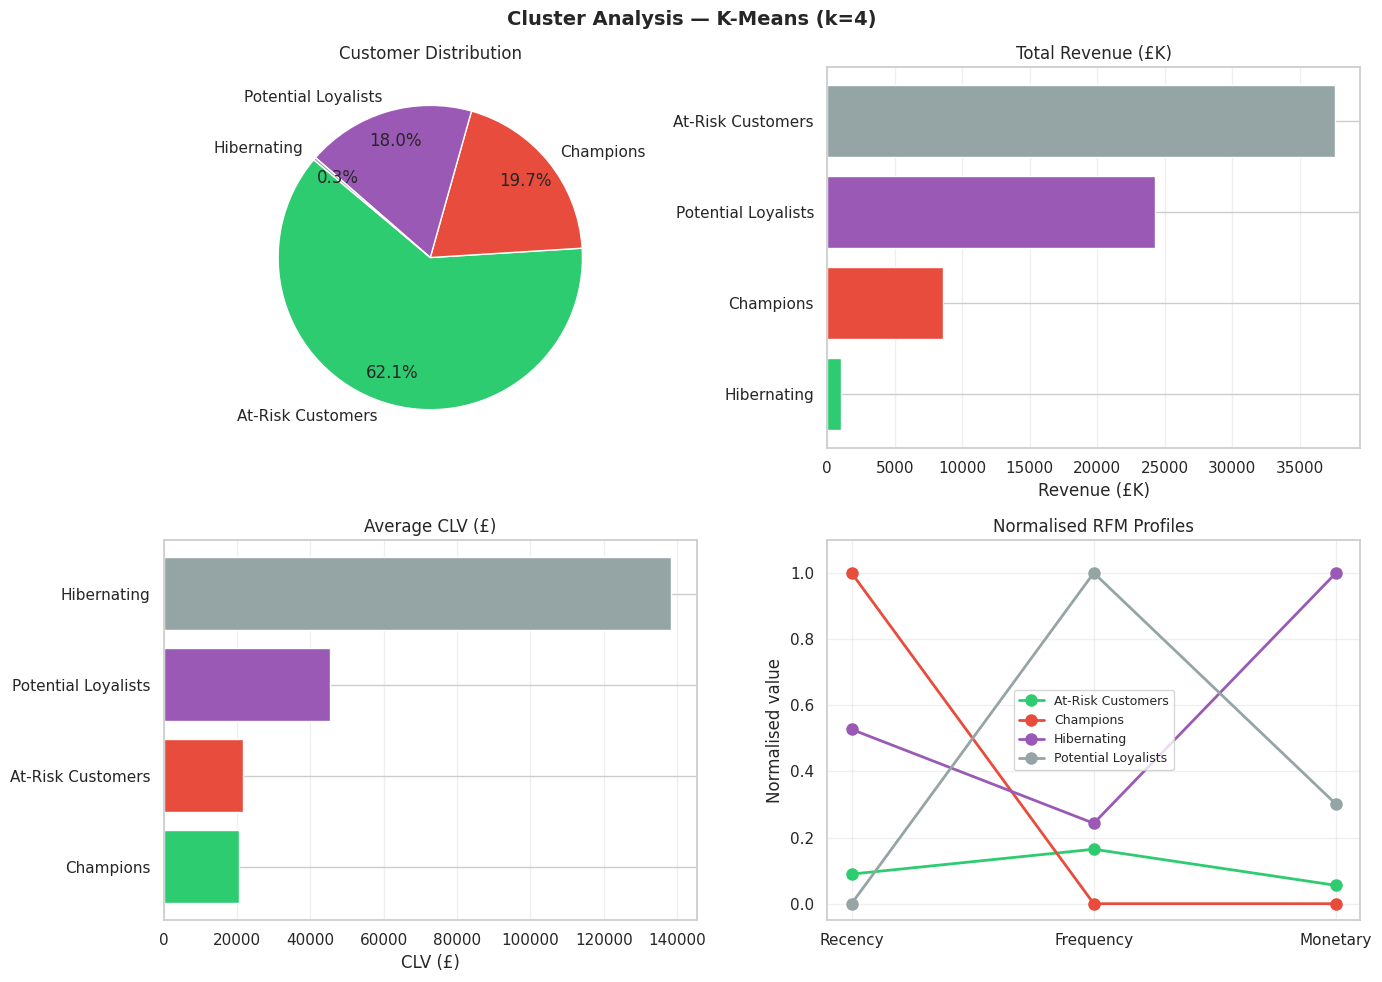

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cluster Analysis — K-Means (k=4)', fontsize=14, fontweight='bold')

palette = ['#2ECC71', '#E74C3C', '#9B59B6', '#95A5A6']

# 6a — Size
cluster_counts = rfm['Cluster_Name'].value_counts()
axes[0,0].pie(cluster_counts.values,
              labels=cluster_counts.index,
              colors=palette, autopct='%1.1f%%',
              startangle=140, pctdistance=0.8)
axes[0,0].set_title('Customer Distribution')

# 6b — Revenue share
rev_by_seg = rfm.groupby('Cluster_Name')['Monetary'].sum().sort_values(ascending=True)
axes[0,1].barh(rev_by_seg.index, rev_by_seg.values / 1e3,
               color=palette, edgecolor='white')
axes[0,1].set_title('Total Revenue (£K)')
axes[0,1].set_xlabel('Revenue (£K)')
axes[0,1].grid(axis='x', alpha=0.3)

# 6c — Avg CLV
clv_by_seg = rfm.groupby('Cluster_Name')['CLV'].mean().sort_values(ascending=True)
axes[1,0].barh(clv_by_seg.index, clv_by_seg.values,
               color=palette, edgecolor='white')
axes[1,0].set_title('Average CLV (£)')
axes[1,0].set_xlabel('CLV (£)')
axes[1,0].grid(axis='x', alpha=0.3)

# 6d — RFM radar (snake plot)
rfm_cols = ['Recency', 'Frequency', 'Monetary']
means_rfm = rfm.groupby('Cluster_Name')[rfm_cols].mean()
norm_rfm  = (means_rfm - means_rfm.min()) / (means_rfm.max() - means_rfm.min() + 1e-9)
for i, (seg, row) in enumerate(norm_rfm.iterrows()):
    axes[1,1].plot(rfm_cols, row.values, 'o-', label=seg,
                   color=palette[i], linewidth=2, markersize=8)
axes[1,1].set_title('Normalised RFM Profiles')
axes[1,1].set_ylabel('Normalised value')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig(PLOT_DIR / '18_cluster_analysis.png', dpi=150)
plt.show()


## 7. Marketing action plan (ready for CRM export)

In [7]:
action_plan = []
for _, row in rfm.iterrows():
    seg = row['Cluster_Name']
    # Match to profile dict (use generic fallback if not found)
    profile = PROFILES.get(seg, PROFILES.get('Hibernating'))
    action_plan.append({
        'CustomerID':   int(row.name) if not pd.isna(row.name) else 0,
        'Segment':      seg,
        'Retention_Risk':   profile['retention_risk'],
        'Upsell_Potential': profile['upsell'],
        'Action_1':     profile['strategy'][0],
        'Action_2':     profile['strategy'][1] if len(profile['strategy']) > 1 else '',
    })

action_df = pd.DataFrame(action_plan)
action_df.to_csv(PROC_DIR / 'marketing_action_plan.csv', index=False)
print(f'Marketing action plan saved: {len(action_df):,} customers')
action_df.head(5)


Marketing action plan saved: 3,155 customers


,CustomerID,Segment,Retention_Risk,Upsell_Potential,Action_1,Action_2
0,10004,Potential Loyalists,Medium,High,3-email onboarding journey — product education,Second-purchase discount (7-day expiry)
1,10008,At-Risk Customers,High,Low,One reactivation email (no deep discount),Share new product launches to re-spark interest
2,10009,Potential Loyalists,Medium,High,3-email onboarding journey — product education,Second-purchase discount (7-day expiry)
3,10012,At-Risk Customers,High,Low,One reactivation email (no deep discount),Share new product launches to re-spark interest
4,10013,At-Risk Customers,High,Low,One reactivation email (no deep discount),Share new product launches to re-spark interest


## 8. Key business insights

> **These are the insights you'd present to the CMO.**

### Revenue concentration
- The top segment (Champions) generates the lion's share of revenue from a small fraction of customers — classic Pareto
- Losing 10% of Champions is more damaging than losing 50% of Hibernating customers

### Churn risk
- At-Risk customers have historical purchase habits but low recent activity — **reactivation ROI is highest here**
- Cannot Lose Them require personal outreach, not mass email

### Growth opportunity
- Potential Loyalists are in the habit-formation window — a 2nd-purchase incentive now costs £5; recovering a churned customer costs £50+

### Operational
- Batch score customers monthly; flag movements between segments (Champion → At-Risk = early warning)
- Track segment *migration rate* as a KPI, not just size

In [8]:
print('=== FINAL DELIVERABLES ===')
import os
for f in sorted(Path('../data/processed').iterdir()):
    if f.suffix in ['.csv', '.parquet']:
        size = f.stat().st_size / 1024
        print(f'  data/processed/{f.name:<40} {size:>7.1f} KB')
print()
for f in sorted(Path('../models').iterdir()):
    if f.suffix == '.pkl':
        size = f.stat().st_size / 1024
        print(f'  models/{f.name:<45} {size:>7.1f} KB')


=== FINAL DELIVERABLES ===
  data/processed/marketing_action_plan.csv                  378.8 KB
  data/processed/online_retail_clean.csv                   4913.8 KB
  data/processed/online_retail_clean.parquet               1407.0 KB
  data/processed/rfm_clustered.csv                          522.7 KB
  data/processed/rfm_features.csv                           472.7 KB
  data/processed/rfm_features_clustered.csv                 675.3 KB
  data/processed/rfm_scaled.csv                             670.1 KB

  models/feature_names.pkl                                 0.2 KB
  models/kmeans_model.pkl                                 13.8 KB
  models/pca_transformer.pkl                               1.6 KB
  models/scaler.pkl                                        1.1 KB
